<a href="https://www.kaggle.com/code/lalit7881/job-salary-prediction-eda?scriptVersionId=313488738" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hosan707/job-salary-prediction-dataset/job_salary_prediction_dataset.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/hosan707/job-salary-prediction-dataset/job_salary_prediction_dataset.csv")

In [3]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [4]:
df.tail()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467
249999,Data Analyst,16,Diploma,2,Technology,Medium,UK,No,5,133084


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [6]:
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

In [7]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [8]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

job_title           object
experience_years     int64
education_level     object
skills_count         int64
industry            object
company_size        object
location            object
remote_work         object
certifications       int64
salary               int64
dtype: object

In [11]:
df.shape

(250000, 10)

In [12]:
df.nunique()

job_title               12
experience_years        21
education_level          5
skills_count            19
industry                10
company_size             5
location                10
remote_work              3
certifications           6
salary              118956
dtype: int64

## EDA


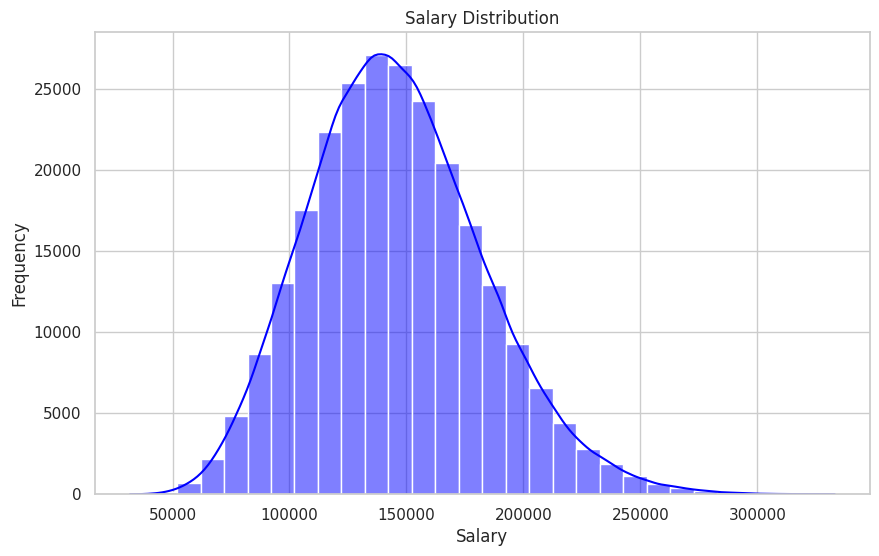

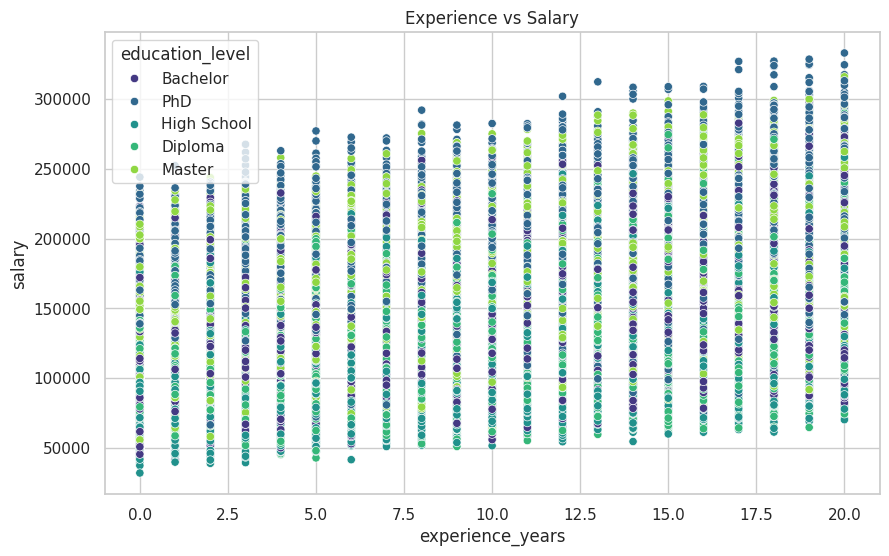

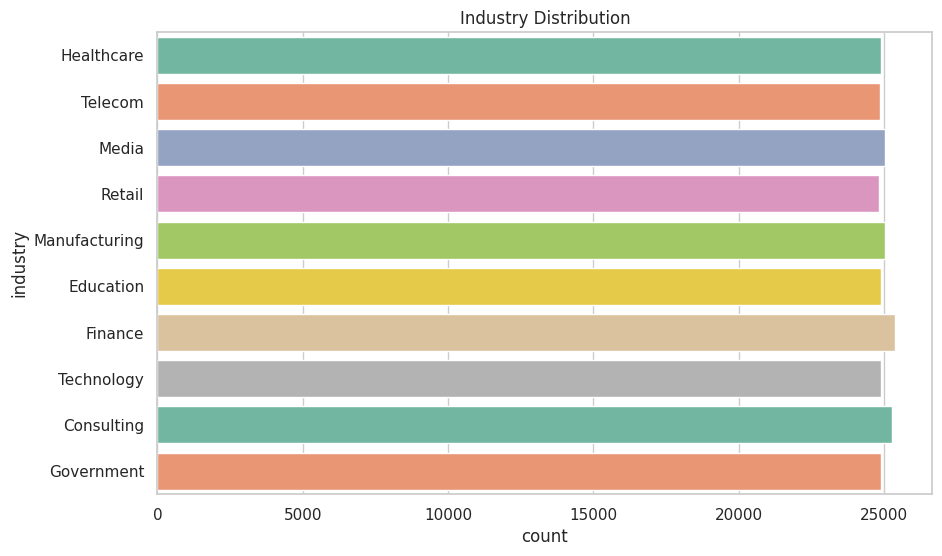

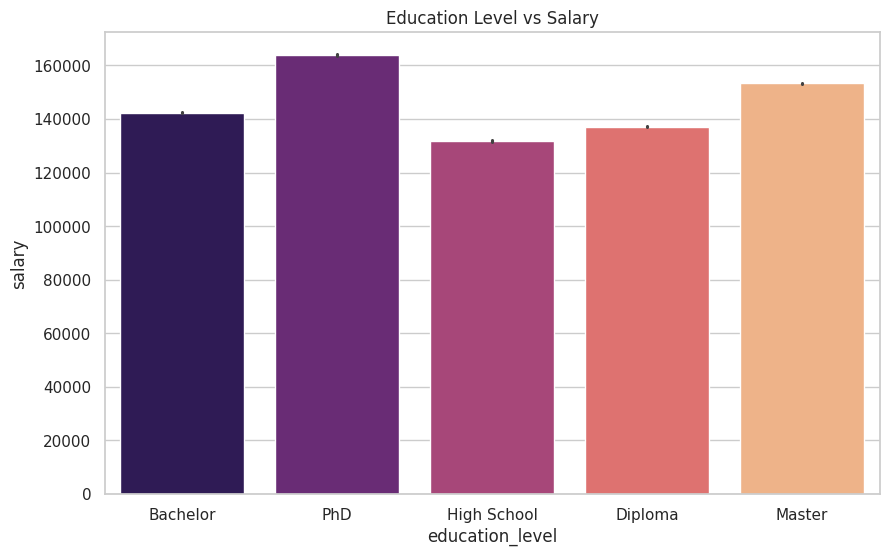

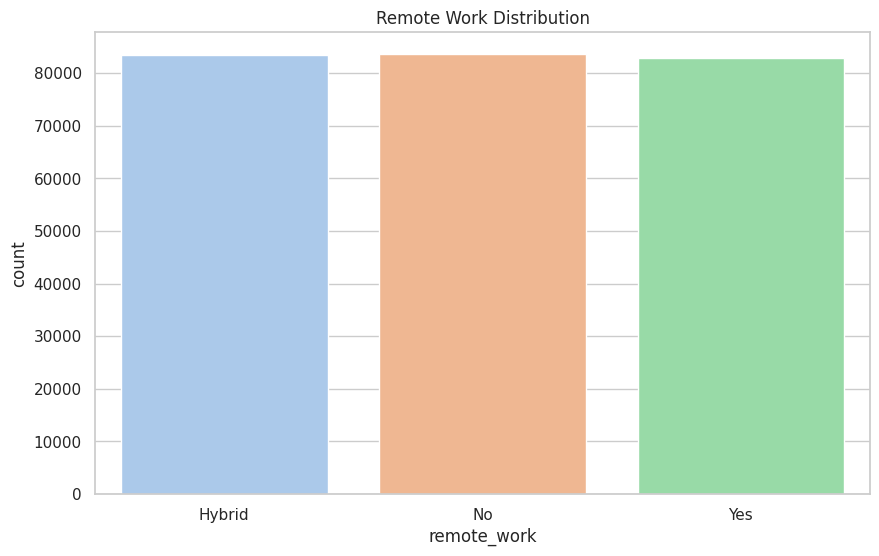

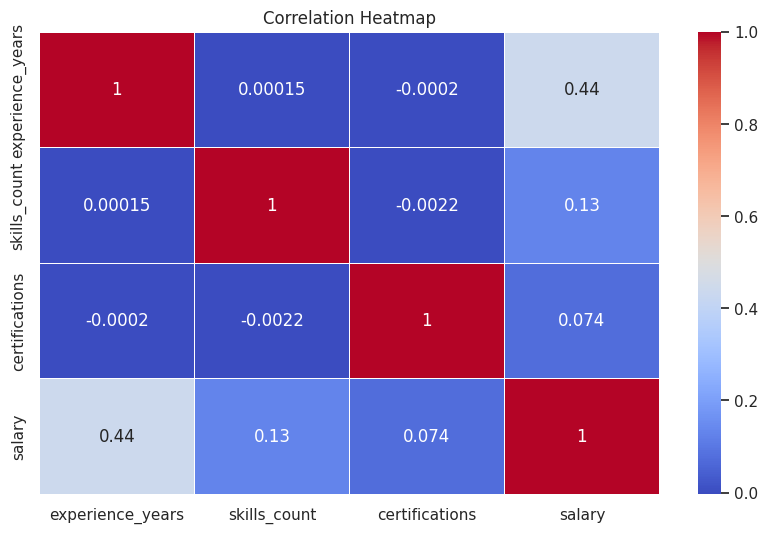

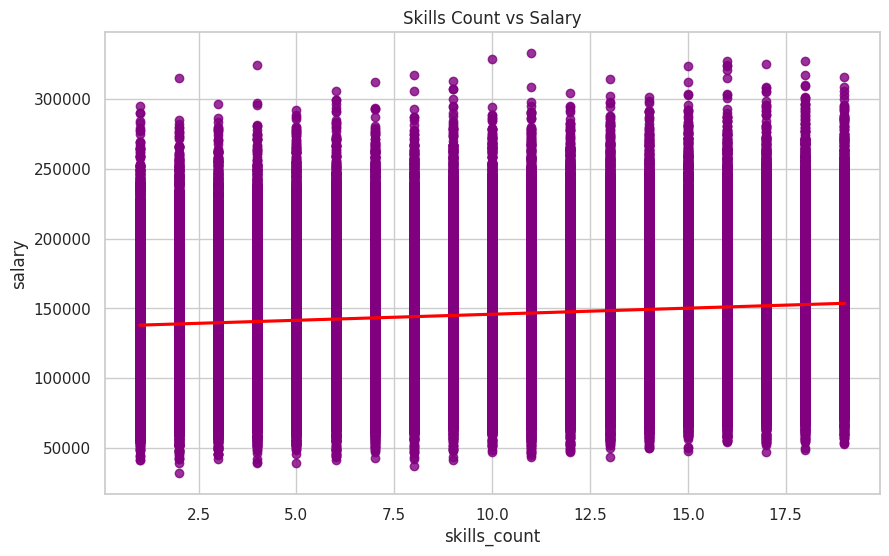

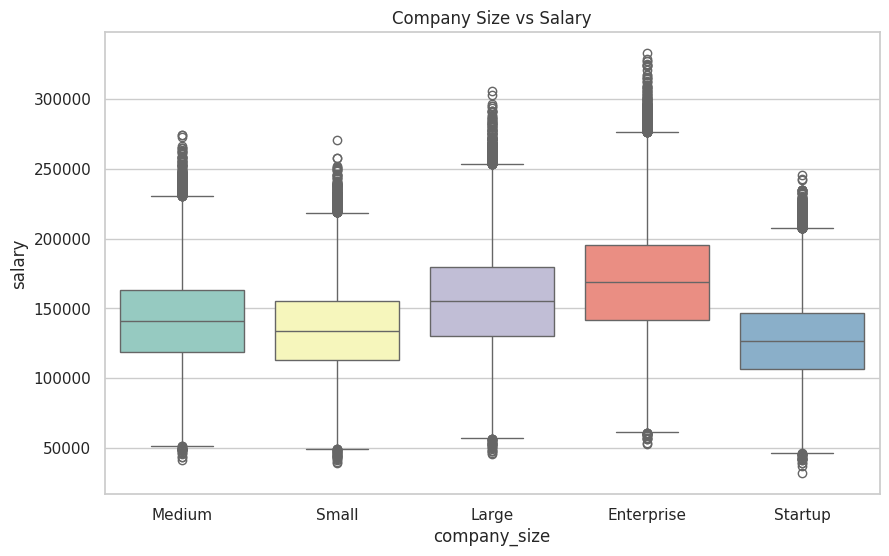

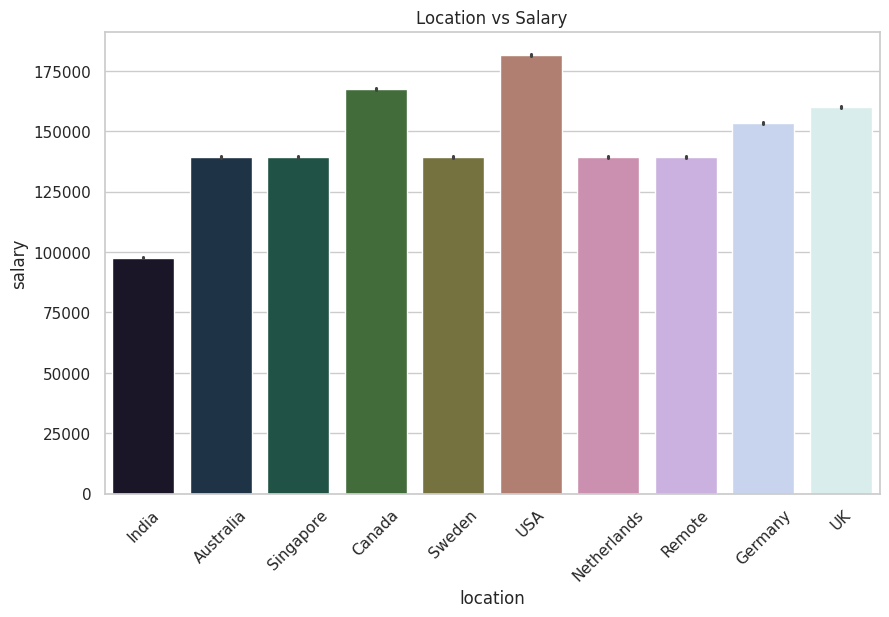

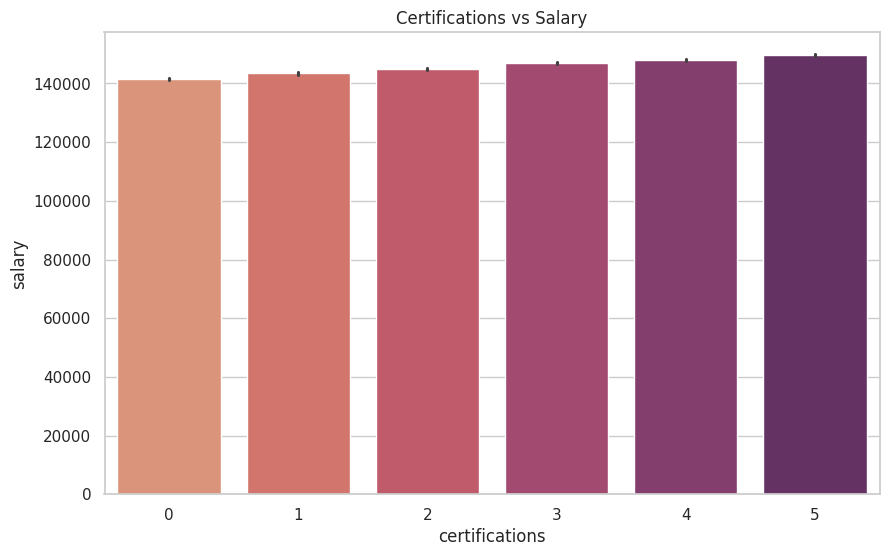

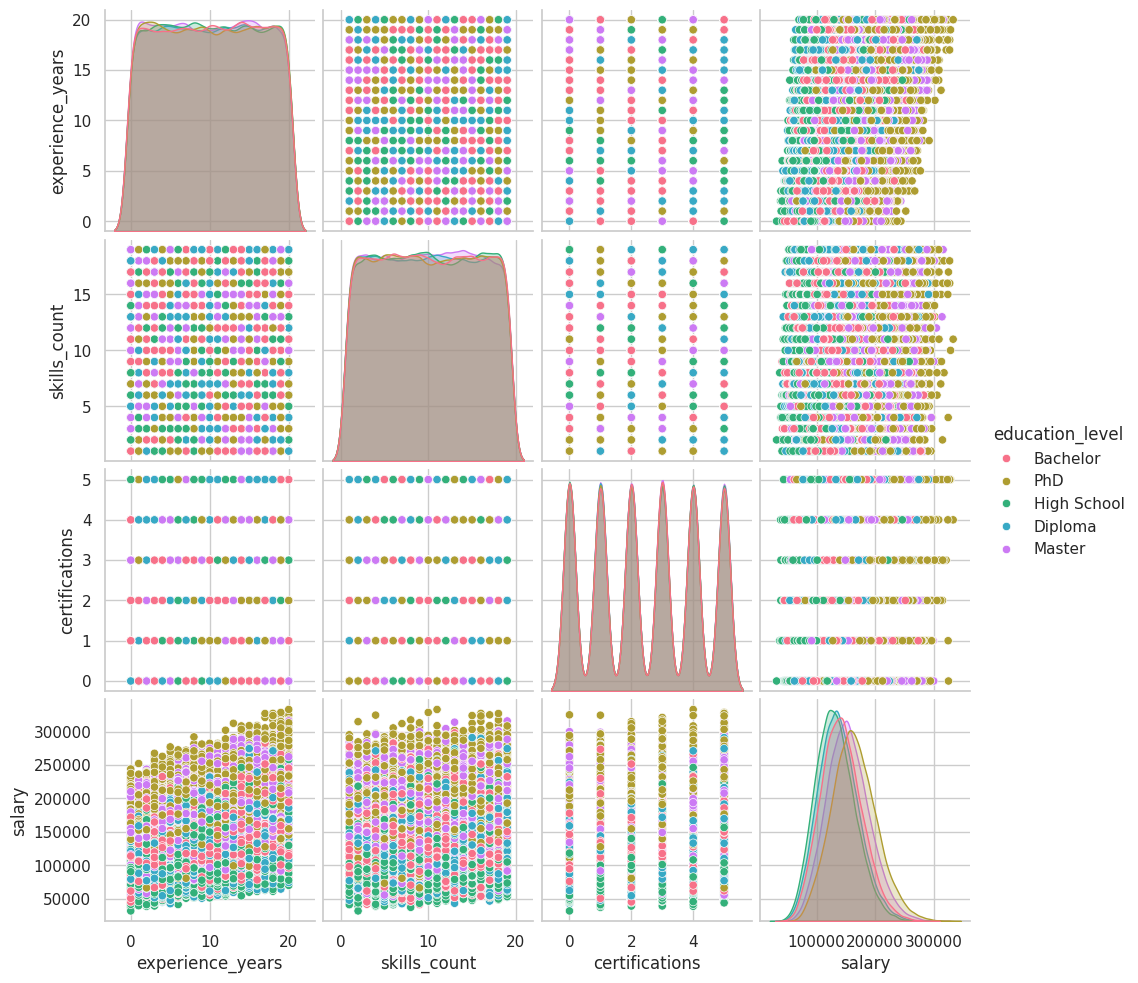

In [13]:
import plotly.express as px


# -------------------------
# 2. Basic Cleaning
# -------------------------
df = df.dropna()

# -------------------------
# 3. Set Style
# -------------------------
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# -------------------------
# 4. Salary Distribution
# -------------------------
plt.figure()
sns.histplot(df['salary'], bins=30, kde=True, color='blue')
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

# -------------------------
# 5. Experience vs Salary
# -------------------------
plt.figure()
sns.scatterplot(
    x='experience_years',
    y='salary',
    data=df,
    hue='education_level',
    palette='viridis'
)
plt.title("Experience vs Salary")
plt.show()

# -------------------------
# 6. Industry Distribution
# -------------------------
plt.figure()
sns.countplot(
    y='industry',
    data=df,
    palette='Set2'
)
plt.title("Industry Distribution")
plt.show()

# -------------------------
# 7. Education vs Salary
# -------------------------
plt.figure()
sns.barplot(
    x='education_level',
    y='salary',
    data=df,
    palette='magma'
)
plt.title("Education Level vs Salary")
plt.show()

# -------------------------
# 8. Remote Work Distribution
# -------------------------
plt.figure()
sns.countplot(
    x='remote_work',
    data=df,
    palette='pastel'
)
plt.title("Remote Work Distribution")
plt.show()

# -------------------------
# 9. Correlation Heatmap
# -------------------------
plt.figure()
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()

# -------------------------
# 10. Skills vs Salary
# -------------------------
plt.figure()
sns.regplot(
    x='skills_count',
    y='salary',
    data=df,
    scatter_kws={'color': 'purple'},
    line_kws={'color': 'red'}
)
plt.title("Skills Count vs Salary")
plt.show()

# -------------------------
# 11. Company Size vs Salary
# -------------------------
plt.figure()
sns.boxplot(
    x='company_size',
    y='salary',
    data=df,
    palette='Set3'
)
plt.title("Company Size vs Salary")
plt.show()

# -------------------------
# 12. Location vs Salary
# -------------------------
plt.figure()
sns.barplot(
    x='location',
    y='salary',
    data=df,
    palette='cubehelix'
)
plt.xticks(rotation=45)
plt.title("Location vs Salary")
plt.show()

# -------------------------
# 13. Certifications vs Salary
# -------------------------
plt.figure()
sns.barplot(
    x='certifications',
    y='salary',
    data=df,
    palette='flare'
)
plt.title("Certifications vs Salary")
plt.show()

# -------------------------
# 14. Pairplot (Overview)
# -------------------------
sns.pairplot(
    df,
    hue='education_level',
    palette='husl'
)
plt.show()

# -------------------------
# 15. Interactive Plot (Plotly)
# -------------------------
fig = px.scatter(
    df,
    x='experience_years',
    y='salary',
    color='industry',
    size='skills_count',
    title="Interactive Experience vs Salary"
)
fig.show()

## Feature engineering

Logistic Regression Accuracy: 0.9558
Random Forest Accuracy: 0.9429


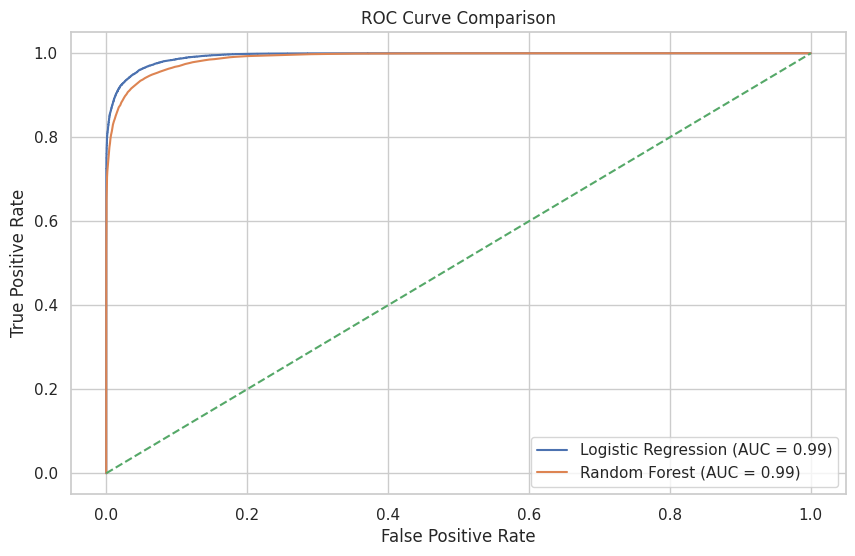

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc

# -------------------------
# 2. Basic Cleaning
# -------------------------
df = df.dropna()

# -------------------------
# 3. Convert Salary to Target (Classification)
# Example: High vs Low salary
# -------------------------
median_salary = df['salary'].median()
df['salary_class'] = (df['salary'] > median_salary).astype(int)

# -------------------------
# 4. Features & Target
# -------------------------
X = df.drop(['salary', 'salary_class'], axis=1)
y = df['salary_class']

# -------------------------
# 5. Identify Column Types
# -------------------------
categorical_cols = [
    'job_title', 'education_level', 'industry',
    'company_size', 'location', 'remote_work'
]

numerical_cols = [
    'experience_years', 'skills_count', 'certifications'
]

# -------------------------
# 6. Preprocessing Pipeline (NO LEAKAGE)
# -------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# -------------------------
# 7. Train-Test Split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------
# 8. Models
# -------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# -------------------------
# 9. Train, Predict, Evaluate
# -------------------------
plt.figure()

for name, model in models.items():
    
    # Full pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train ONLY on training data
    pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# -------------------------
# 10. Plot ROC Curve
# -------------------------
plt.plot([0, 1], [0, 1], linestyle='--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()